# AI Lab 2: Oodles and Oodles of Models
**Course:** DS 7331 – Artificial Intelligence I 
**Team Members:** Johnny Vogt, Drew Nunnally, Devin Streeter, Mike Flores  
**Date:** 3/8/2026

# Business Understanding

The goal of this project is to develop a machine learning model capable of identifying phishing websites based on structural characteristics of URLs and webpage attributes. Phishing websites are designed to mimic legitimate services in order to steal user credentials, financial information, or other sensitive data.

Detecting phishing websites is an important cybersecurity problem because users often cannot visually distinguish fraudulent websites from legitimate ones. Automated detection models can assist security systems, browsers, and email providers by flagging suspicious websites before users interact with them.

The primary objective of this analysis is therefore to build classification models that can accurately identify high-risk phishing websites using features extracted from URLs and website structures.

These models could potentially be used in:

- browser security filters
- email spam/phishing detection systems
- enterprise security gateways
- financial fraud monitoring systems

The primary objective of this analysis is therefore to build classification models that can accurately address two main tasks:

- **Task 1: High-Risk Payment Detection**. Accurately identifying high-risk phishing payment websites (the HighRiskPay or HRP model).

- **Task 2: General Phishing Detection**. Classifying general phishing websites (the label model).

The success of the model will be measured using classification performance metrics such as accuracy, precision, recall, and F1-score, with particular attention to recall since failing to detect a phishing website can have serious security consequences.

# Data Understanding

The dataset used in this project contains features describing structural characteristics of websites and URLs that are commonly associated with phishing attacks. These features include indicators related to domain structure, URL patterns, and webpage behavior.

Initial exploration of the dataset was performed to understand the distribution of the variables and the balance between phishing and non-phishing observations. Summary statistics and exploratory visualizations were used to identify potential anomalies, verify variable types, and ensure that the dataset was appropriate for classification modeling. The dataset contains 235,795 observations and 53 predictor variables after preprocessing. The binary target variable HighRiskPay represents whether a website is classified as a high-risk phishing payment site.

Understanding the structure of the data prior to modeling helps ensure that preprocessing decisions such as feature selection, scaling, and variable representation are appropriate for the machine learning algorithms used later in the analysis.

# Data Preparation and Preprocessing

## Overview
The dataset used in this analysis contains information describing characteristics of websites and URLs that may indicate phishing behavior. Before building classification models, the dataset required preprocessing to ensure that the variables were in a form suitable for machine learning algorithms and that the resulting models would be stable, interpretable, and capable of generalizing to unseen data. The preprocessing steps included verifying variable types, selecting an appropriate target variable for classification, handling feature representations, and preparing the feature matrix used for modeling.

## Target Variable
The classification task in this analysis is to predict whether a website should be considered high-risk for phishing behavior, based on a set of structural and behavioral features extracted from URLs and website attributes. The target variable HighRiskPay was engineered during preprocessing using the Pay and label variables. After the target variable was created, the variables Pay and label were removed from the feature set to prevent data leakage during model training.

The target variables selected for these tasks is:

**HighRiskPay**

This variable represents whether a website supports payment functionality that may indicate phishing or fraudulent activity. The variable is represented as a binary classification outcome, where:

**1 = High risk phishing payment site**  
**0 = Not high risk**

Representing the class variable as a binary numeric indicator allows classification algorithms such as logistic regression, Naive Bayes, and K-Nearest Neighbors to directly learn the relationship between the features and the phishing outcome.

## Feature Representation

The dataset includes multiple variables describing characteristics of URLs and webpage structures. These features capture information such as domain properties, structural patterns in the URL, and other indicators often associated with phishing websites.

All features used for modeling were represented numerically so that they could be interpreted by machine learning algorithms. Numeric representations are necessary because most classification algorithms operate on mathematical relationships between features and the target variable.

The preprocessing therefore ensured that all predictor variables were in a numeric format (integers or floating-point values) so that distance-based and probabilistic models could correctly interpret them.

## Preventing Data Leakage

During preprocessing, several variables were identified as potential sources of data leakage. The target variable **HighRiskPay** was engineered using the variables **Pay** and **label**:

HighRiskPay = 1 if Pay == 1 AND label == 0

Because HighRiskPay is derived directly from Pay and label, including those variables in the model would create target leakage. These variables directly determine the target outcome, including them in the predictor feature set would allow the model to infer the answer without learning meaningful patterns from the website characteristics.

To prevent this issue, the following variables were removed from the predictor feature matrix prior to model training:

- Pay  
- label  

The variables Pay and label were removed from the predictor dataset prior to model training and cross-validation to ensure that the models did not have access to information used to construct the target variable. The engineered variable HighRiskPay was retained as the target variable, but excluded from the predictor set used to train the classification models.

## Feature Selection

Only variables relevant to the phishing detection task were retained for modeling. Features that did not contribute useful predictive information or that duplicated other variables were removed from the modeling dataset.

The final feature set therefore contains only structural and behavioral attributes of the websites. This ensures that the classification models learn patterns associated with phishing behavior rather than relying on information embedded in the construction of the target variable.

Feature selection serves several purposes:

- Improves model interpretability by focusing only on relevant predictors  
- Reduces noise that can degrade predictive performance  
- Prevents unnecessary model complexity  
- Improves computational efficiency  

Removing unnecessary variables also helps reduce the risk of overfitting, where a model memorizes noise rather than learning general patterns. After removing Pay, label, and HighRiskPay from the predictor matrix to prevent data leakage, the final modeling dataset used for training contained 235,795 observations and 53 predictor variables.

## Creation of HighRiskPay (HRP)

The HRP variable is engineered by combining two existing features: the payment indicator and the base label. It is created using the following logic:

`HighRiskPay = 1` IF `Pay == 1` AND `label == 0`
OTHERWISE `HighRiskPay = 0`

This logic isolates instances where a site explicitly requests payment (Pay == 1) but exhibits the dataset's specific phishing label condition (label == 0). By combining these conditions, the HRP variable flags the subset of sites that represent the highest financial risk.

## Feature Scaling

Some machine learning algorithms are sensitive to the scale of the input features. In particular, distance-based algorithms such as K-Nearest Neighbors rely on calculating distances between observations in feature space. If one variable has a much larger numerical range than another, it may dominate the distance calculation and bias the model.

To prevent this issue, scaling was applied so that features contribute more equally to the model. Feature scaling ensures that all variables operate within comparable numeric ranges, which stabilizes training and improves model generalization.

Standardization using StandardScaler was applied to the predictor variables prior to model training. This transformation centers the variables around zero and scales them to unit variance, which improves the performance of distance-based models such as K-Nearest Neighbors. Because the K-Nearest Neighbors algorithm relies on distance calculations between observations, predictor variables were standardized prior to model training. Standardization ensures that variables measured on larger numeric scales do not dominate the distance metric and allows each feature to contribute equally to the distance calculation.

## Feature Importance

Understanding which attributes contribute most strongly to phishing detection helps explain model behavior and provides insight into the characteristics of fraudulent websites. Identifying influential predictors also improves model interpretability and provides useful information for cybersecurity analysts designing detection systems.

Feature importance was evaluated by examining the coefficients of the logistic regression model and analyzing how different variables influence prediction outcomes. Because logistic regression is a linear model, the magnitude and sign of the coefficients provide insight into how each feature influences the probability that a website is classified as phishing.

Exploratory Data Analysis (EDA) suggested that attributes related to domain structure, URL characteristics, and webpage behavior play an important role in identifying phishing websites. These features capture structural patterns commonly associated with malicious websites, such as suspicious domain configurations, abnormal URL structures, and unusual webpage behaviors used to mimic legitimate services.

The Naive Bayes model does not provide interpretable coefficients in the same way as logistic regression. Instead, it estimates class probabilities based on the likelihood of observed features under an independence assumption. While this approach can perform well for classification tasks, it provides limited direct insight into the relative importance of individual predictors.

Similarly, K-Nearest Neighbors (KNN) is a distance-based algorithm and does not produce model parameters that indicate feature importance. Predictions are generated by comparing observations in feature space and assigning the class most common among the nearest neighbors. As a result, KNN focuses on local similarity patterns rather than producing explicit measures of feature influence.

Because logistic regression provides interpretable coefficients while also achieving the strongest predictive performance in this analysis, it offers both strong classification accuracy and meaningful insight into the factors associated with phishing websites.

## Handling of Missing or Inconsistent Values

During preprocessing, the dataset was reviewed to ensure that missing values or inconsistent feature representations would not interfere with model training. Any inconsistencies were addressed during the data preparation phase to ensure that the dataset used for modeling contained valid numerical inputs for each observation.

Maintaining a clean dataset ensures that classification algorithms can successfully learn relationships between features and the target variable without errors or unintended bias.

## Final Modeling Dataset

After preprocessing, the final dataset consisted of:

- A binary target variable representing phishing risk
- A set of numeric predictor variables describing website and URL characteristics
- Clean and consistent feature representations suitable for machine learning algorithms

This prepared dataset was then used to train and evaluate multiple classification models using cross-validation to ensure reliable estimates of predictive performance.

# Model Validation Strategy

To evaluate model performance in a realistic manner, the dataset was divided into training and testing subsets. The training set was used to fit the models, while the testing set was used to evaluate predictive performance on unseen data.

In addition to the train/test split, cross-validation was used to produce more stable performance estimates. Cross-validation reduces the risk that the results depend on a single random split of the data and provides a more reliable estimate of model generalization performance.

This approach ensures that the reported metrics represent the expected performance of the model when applied to new phishing detection tasks.

Accuracy measures overall prediction correctness, precision measures how many predicted phishing sites were actually phishing, recall measures how many phishing sites were successfully detected, and the F1-score balances precision and recall.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display utilities
from IPython.display import display

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Import dataset
df = pd.read_csv(r"C:\Users\Eight\Documents\MSDS\MSDS_7331_Artificial_Intelligence1\AI-ML-DS-7331\Lab2\PhiUSIIL_Phishing_URL_Dataset.csv")

# Sanity-Check the dataset
rows, cols = df.shape
print(f"The dataset contains {rows:,} rows and {cols} columns.")

# Check for duplicate rows
print("Duplicate Rows")
# Counts ONLY exact row level duplicates
display(df.duplicated().sum())

print("Duplicate URLs (only)")
# Many URLs appear more than once, but with small differences in feature values
# These are NOT full row duplicates, only URL-level duplicates
# Count duplicate values based only on the URL column
# It is safe to just drop all duplicates
display(df.duplicated(subset=["URL"]).sum())

# Drop the duplicate URLs code
# Identify duplicate URLs
dup_url_mask = df.duplicated(subset=["URL"], keep=False)

# Remove duplicate URLs (keep the first occurrence)
df_dedup = df.drop_duplicates(subset=["URL"], keep="first")
df_dedup = df_dedup.drop(columns=["FILENAME", "URL", "Domain", "Title", "TLD", "URLSimilarityIndex"], axis =1)

# New column
df_dedup['HighRiskPay'] = np.where(
    (df_dedup['Pay'] == 1 ) & (df_dedup['label'] == 0),
    1,
    0
)

rows, cols = df_dedup.shape
print(f"After dropping the duplicate URLs, the dataset contains {rows:,} rows and {cols} columns.")

# Test/Train Split
feature_cols = df_dedup.columns.drop(['label', 'HighRiskPay','Pay'])
X = df_dedup[feature_cols].values

y_label = df_dedup['label'].values
y_HighRiskPay = df_dedup['HighRiskPay'].values

#Setting up the Cross Validation using ShuffleSplit 
num_cv_iterations = 5
num_instances = len(y_label)

cv_label = StratifiedShuffleSplit(n_splits=num_cv_iterations, test_size=0.2)
cv_HighRiskPay = StratifiedShuffleSplit(n_splits=num_cv_iterations, test_size=0.2)
                         
print(cv_label)
print(cv_HighRiskPay)
print("X shape:", X.shape)
print("y_label shape:", y_label.shape)
print("y_HighRiskPay shape:", y_HighRiskPay.shape )

# Sanity check: HighRiskPay distribution
print("HighRiskPay value counts:")
print(df_dedup['HighRiskPay'].value_counts())

print("\nHighRiskPay normalized (class proportions):")
print(df_dedup['HighRiskPay'].value_counts(normalize=True))

# Extra sanity checks
print("\nUnique values in HighRiskPay:", df_dedup['HighRiskPay'].unique())
print("Any missing in HighRiskPay:", df_dedup['HighRiskPay'].isna().sum())

The dataset contains 235,795 rows and 56 columns.
Duplicate Rows


0

Duplicate URLs (only)


425

After dropping the duplicate URLs, the dataset contains 235,370 rows and 51 columns.
StratifiedShuffleSplit(n_splits=5, random_state=None, test_size=0.2,
            train_size=None)
StratifiedShuffleSplit(n_splits=5, random_state=None, test_size=0.2,
            train_size=None)
X shape: (235370, 48)
y_label shape: (235370,)
y_HighRiskPay shape: (235370,)
HighRiskPay value counts:
HighRiskPay
0    229338
1      6032
Name: count, dtype: int64

HighRiskPay normalized (class proportions):
HighRiskPay
0    0.974372
1    0.025628
Name: proportion, dtype: float64

Unique values in HighRiskPay: [0 1]
Any missing in HighRiskPay: 0


# Modeling Approach

## Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data. Models were trained on the training set and evaluated using accuracy, precision, recall, and F1-score on the test set.

In [2]:
# Create Reusable CVHelper Function to run CV and print metrics
def CVHelper(clf, X, y, cv_object, scale=False, model_name="Model"):
    iter_num = 0
    accs, precs, recs, f1s = [], [], [], []

    for train_idx, test_idx in cv_object.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # only scale if scale=True is passed
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        conf = confusion_matrix(y_test, y_pred)

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

        print(f"Iteration {iter_num+1} - {model_name} Metrics:")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"Confusion Matrix:\n{conf}\n")
        iter_num += 1

    avg_results = {
        "Model": model_name,
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1-Score": np.mean(f1s),
        "F1_all": f1s,        # per-split F1 values
        "Recall_all": recs    # per-split Recall values
    }

    print(f"Average {model_name} Metrics over {iter_num} iterations:")
    print(f"Average Accuracy: {avg_results['Accuracy']:.4f}")
    print(f"Average Precision: {avg_results['Precision']:.4f}")
    print(f"Average Recall: {avg_results['Recall']:.4f}")
    print(f"Average F1-Score: {avg_results['F1-Score']:.4f}")

    return avg_results



# Model Comparison Discussion

Three classification algorithms were evaluated:

**1. Logistic Regression**  
**2. Naive Bayes**  
**3. K-Nearest Neighbors**  

Three classification algorithms were evaluated in this study: Logistic Regression, Naive Bayes, and K-Nearest Neighbors.

- Logistic Regression provides a simple and interpretable model that estimates the probability of a phishing website using a linear relationship between features and the outcome variable.

- Naive Bayes is a probabilistic classifier that assumes conditional independence between features. Although this assumption is often unrealistic, Naive Bayes performs well in many classification problems and is computationally efficient.

- K-Nearest Neighbors (KNN) is a distance-based classifier that predicts the class of a new observation based on the most similar observations in the training data. Because it relies on distance calculations, feature scaling is particularly important for this model.

Each model offers different strengths. Logistic regression provides interpretability, Naive Bayes offers computational efficiency, and KNN captures nonlinear relationships between features and the outcome variable.

# Logistic Regression

In [3]:
# log reg for hrp

lr_hrp = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs')

lr_results = CVHelper(
    clf=lr_hrp,
    X=X,
    y=y_HighRiskPay,
    cv_object=cv_HighRiskPay,
    scale=True,   # turn scaling on
    model_name="Logistic Regression for HighRiskPay"
)

c:\Users\Eight\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Iteration 1 - Logistic Regression for HighRiskPay Metrics:
Accuracy: 0.9068
Precision: 0.2001
Recall: 0.8806
F1-Score: 0.3261
Confusion Matrix:
[[41623  4245]
 [  144  1062]]



c:\Users\Eight\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Iteration 2 - Logistic Regression for HighRiskPay Metrics:
Accuracy: 0.9061
Precision: 0.1997
Recall: 0.8856
F1-Score: 0.3259
Confusion Matrix:
[[41587  4281]
 [  138  1068]]



c:\Users\Eight\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Iteration 3 - Logistic Regression for HighRiskPay Metrics:
Accuracy: 0.9096
Precision: 0.2031
Recall: 0.8648
F1-Score: 0.3289
Confusion Matrix:
[[41775  4093]
 [  163  1043]]



c:\Users\Eight\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Iteration 4 - Logistic Regression for HighRiskPay Metrics:
Accuracy: 0.9107
Precision: 0.2099
Recall: 0.8997
F1-Score: 0.3404
Confusion Matrix:
[[41784  4084]
 [  121  1085]]

Iteration 5 - Logistic Regression for HighRiskPay Metrics:
Accuracy: 0.9077
Precision: 0.2015
Recall: 0.8781
F1-Score: 0.3278
Confusion Matrix:
[[41671  4197]
 [  147  1059]]

Average Logistic Regression for HighRiskPay Metrics over 5 iterations:
Average Accuracy: 0.9082
Average Precision: 0.2028
Average Recall: 0.8818
Average F1-Score: 0.3298


c:\Users\Eight\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Naive Bayes

In [4]:
from sklearn.naive_bayes import GaussianNB

nb_hrp  = GaussianNB()

nb_results = CVHelper(
    clf=nb_hrp,
    X=X,
    y=y_HighRiskPay,
    cv_object=cv_HighRiskPay,
    scale=True,   # Needed for NB since the features are on different scales (e.g. URLLength:"1521345" vs. HasPay:"0,1")
    model_name="Naive Bayes for HighRiskPay"
)

Iteration 1 - Naive Bayes for HighRiskPay Metrics:
Accuracy: 0.7160
Precision: 0.0736
Recall: 0.8698
F1-Score: 0.1357
Confusion Matrix:
[[32657 13211]
 [  157  1049]]

Iteration 2 - Naive Bayes for HighRiskPay Metrics:
Accuracy: 0.6956
Precision: 0.0698
Recall: 0.8823
F1-Score: 0.1293
Confusion Matrix:
[[31681 14187]
 [  142  1064]]

Iteration 3 - Naive Bayes for HighRiskPay Metrics:
Accuracy: 0.7136
Precision: 0.0747
Recall: 0.8939
F1-Score: 0.1379
Confusion Matrix:
[[32515 13353]
 [  128  1078]]

Iteration 4 - Naive Bayes for HighRiskPay Metrics:
Accuracy: 0.6737
Precision: 0.0667
Recall: 0.9030
F1-Score: 0.1242
Confusion Matrix:
[[30625 15243]
 [  117  1089]]

Iteration 5 - Naive Bayes for HighRiskPay Metrics:
Accuracy: 0.6949
Precision: 0.0707
Recall: 0.8988
F1-Score: 0.1312
Confusion Matrix:
[[31629 14239]
 [  122  1084]]

Average Naive Bayes for HighRiskPay Metrics over 5 iterations:
Average Accuracy: 0.6988
Average Precision: 0.0711
Average Recall: 0.8896
Average F1-Score: 0.131

# K-Nearest Neighbors

In [5]:
from sklearn.neighbors import KNeighborsClassifier

knn_results_list = []

for k in (3, 5, 7, 9, 11, 13, 15):  # 3 -15 Odds Only to avoid ties in KNN
    knn_hrp = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='minkowski',
        p=2
    )
    result = CVHelper(
        clf=knn_hrp,
        X=X,
        y=y_HighRiskPay,
        cv_object=cv_HighRiskPay,
        scale=True,
        model_name=f"KNN (k={k}) for HighRiskPay"
    )
    knn_results_list.append(result)

    knn_df = pd.DataFrame(knn_results_list)
display(knn_df)

# Pick best model by highest F1-Score
best_idx = knn_df['F1-Score'].idxmax()
best_row = knn_df.loc[best_idx]
knn_results = knn_df.loc[best_idx].to_dict()

print("\nBest KNN configuration based on F1-Score:")
print(best_row)

Iteration 1 - KNN (k=3) for HighRiskPay Metrics:
Accuracy: 0.9904
Precision: 0.8735
Recall: 0.7330
F1-Score: 0.7971
Confusion Matrix:
[[45740   128]
 [  322   884]]

Iteration 2 - KNN (k=3) for HighRiskPay Metrics:
Accuracy: 0.9906
Precision: 0.8735
Recall: 0.7388
F1-Score: 0.8005
Confusion Matrix:
[[45739   129]
 [  315   891]]

Iteration 3 - KNN (k=3) for HighRiskPay Metrics:
Accuracy: 0.9910
Precision: 0.8689
Recall: 0.7637
F1-Score: 0.8129
Confusion Matrix:
[[45729   139]
 [  285   921]]

Iteration 4 - KNN (k=3) for HighRiskPay Metrics:
Accuracy: 0.9904
Precision: 0.8757
Recall: 0.7305
F1-Score: 0.7966
Confusion Matrix:
[[45743   125]
 [  325   881]]

Iteration 5 - KNN (k=3) for HighRiskPay Metrics:
Accuracy: 0.9906
Precision: 0.8724
Recall: 0.7430
F1-Score: 0.8025
Confusion Matrix:
[[45737   131]
 [  310   896]]

Average KNN (k=3) for HighRiskPay Metrics over 5 iterations:
Average Accuracy: 0.9906
Average Precision: 0.8728
Average Recall: 0.7418
Average F1-Score: 0.8019
Iteration 

,Model,Accuracy,Precision,Recall,F1-Score,F1_all,Recall_all
0,KNN (k=3) for HighRiskPay,0.990615,0.872821,0.741791,0.801922,"[0.7971145175834085, 0.8005390835579514, 0.812...","[0.7330016583747927, 0.7388059701492538, 0.763..."
1,KNN (k=5) for HighRiskPay,0.990521,0.891878,0.716915,0.794816,"[0.784350256171402, 0.782246879334258, 0.80329...","[0.6981757877280266, 0.7014925373134329, 0.728..."
2,KNN (k=7) for HighRiskPay,0.990390,0.901211,0.701824,0.789099,"[0.8007448789571695, 0.7913003239241092, 0.778...","[0.7131011608623549, 0.7089552238805971, 0.692..."
3,KNN (k=9) for HighRiskPay,0.990092,0.904126,0.686235,0.780079,"[0.771996215704825, 0.7799337434926644, 0.7748...","[0.6766169154228856, 0.6832504145936982, 0.669..."
4,KNN (k=11) for HighRiskPay,0.989816,0.907257,0.671144,0.771474,"[0.7646493756003843, 0.7819548872180451, 0.766...","[0.6600331674958541, 0.6898839137645107, 0.661..."
5,KNN (k=13) for HighRiskPay,0.989680,0.903491,0.668657,0.768518,"[0.7521448999046711, 0.7756074321105288, 0.769...","[0.654228855721393, 0.6749585406301825, 0.6741..."
6,KNN (k=15) for HighRiskPay,0.989565,0.911799,0.656219,0.763100,"[0.7590887057682986, 0.7563106796116504, 0.776...","[0.6492537313432836, 0.6459369817578773, 0.677..."



Best KNN configuration based on F1-Score:
Model                                 KNN (k=3) for HighRiskPay
Accuracy                                               0.990615
Precision                                              0.872821
Recall                                                 0.741791
F1-Score                                               0.801922
F1_all        [0.7971145175834085, 0.8005390835579514, 0.812...
Recall_all    [0.7330016583747927, 0.7388059701492538, 0.763...
Name: 0, dtype: object


## Performance Metrics Comparison Table

In [6]:
#Buidling Table for all the models and their metrics
all_results = [lr_results, nb_results, knn_results]
results_df = pd.DataFrame(all_results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1-Score,F1_all,Recall_all
0,Logistic Regression for HighRiskPay,0.908174,0.202848,0.881758,0.329810,"[0.3261169967756794, 0.32585812356979404, 0.32...","[0.8805970149253731, 0.8855721393034826, 0.864..."
1,Naive Bayes for HighRiskPay,0.698776,0.071090,0.889552,0.131638,"[0.13565239881029353, 0.12930667800935772, 0.1...","[0.8698175787728026, 0.8822553897180763, 0.893..."
2,KNN (k=3) for HighRiskPay,0.990615,0.872821,0.741791,0.801922,"[0.7971145175834085, 0.8005390835579514, 0.812...","[0.7330016583747927, 0.7388059701492538, 0.763..."


## Model Evaluation

Based on the evaluation metrics, the K-Nearest Neighbors model produced the strongest overall performance among the three algorithms. KNN achieved the highest accuracy, precision, and F1-score, indicating that it provides the best balance between correctly identifying phishing websites and minimizing incorrect classifications.

Logistic Regression performed well in terms of recall, meaning it successfully identified a large proportion of phishing websites. However, its lower precision indicates a higher number of false positives compared to KNN. Naive Bayes produced the weakest performance across most evaluation metrics, suggesting that the independence assumption of the model may not align well with the relationships present in the dataset.

Confidence intervals were computed for the evaluation metrics to assess the stability of model performance. Confidence intervals were estimated using the cross-validation results from the 5-fold evaluation procedure. The intervals reflect the variability in model performance across the validation folds. These intervals represent the range within which the true model performance is expected to fall with 95% confidence. The relatively narrow confidence intervals suggest that the estimated performance metrics are stable across repeated sampling and that the models are likely to perform consistently when applied to new phishing detection data.

# General Phising Detection Task Model Comparison

For the second task, Logistic Regression, Naive Bayes, and K-Nearest Neighbors were trained specifically to predict the `HighRiskPay` target. A 5-fold cross-validation strategy was used to fit the models on training data and evaluate predictive performance on unseen data, reducing the risk of relying on a single random split.

In [7]:
# 95% CI for F1 for All Models
import numpy as np

def print_ci(name, values):
    vals = np.array(values)
    mean = vals.mean()
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se
    print(f"{name} F1 95% CI: mean={mean:.4f}, CI=({ci_low:.4f}, {ci_high:.4f})")

print_ci("Logistic Regression", lr_results["F1_all"])
print_ci("Naive Bayes", nb_results["F1_all"])
print_ci("KNN", knn_results["F1_all"])


Logistic Regression F1 95% CI: mean=0.3298, CI=(0.3245, 0.3351)
Naive Bayes F1 95% CI: mean=0.1316, CI=(0.1269, 0.1364)
KNN F1 95% CI: mean=0.8019, CI=(0.7961, 0.8077)


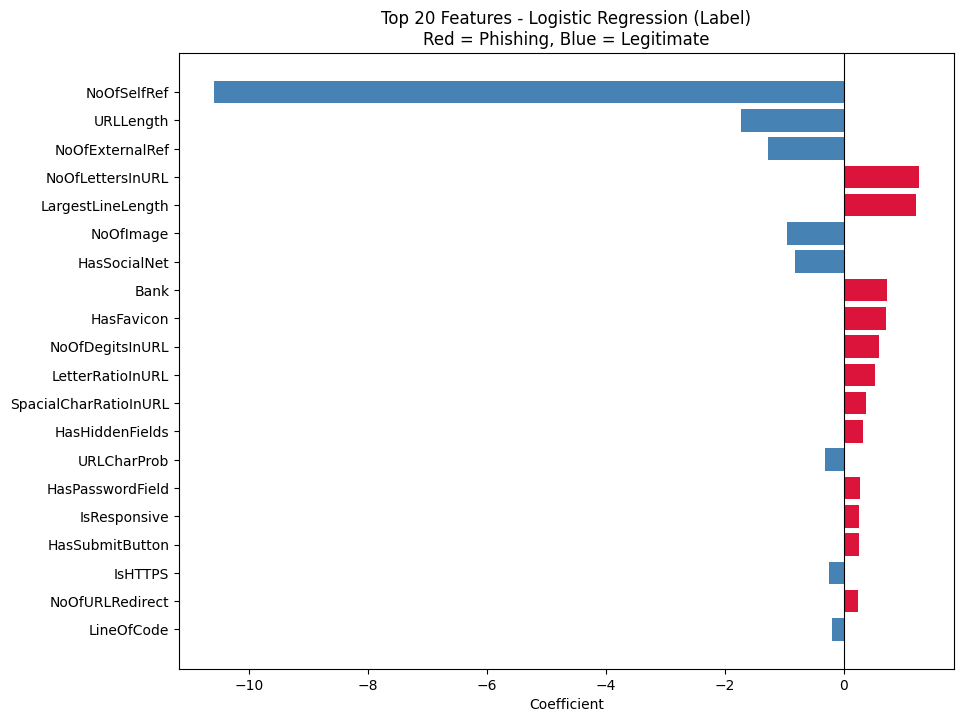

In [ ]:
import matplotlib.pyplot as plt
 
# Refit on full data to get coefficients
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
lr_label_full = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=1000)
lr_label_full.fit(X_scaled, y_HighRiskPay)
 
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_label_full.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)
 
plt.figure(figsize=(10, 8))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Logistic Regression (High Risk Pay)\nRed = High Risk Pay, Blue = Legitimate')
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()

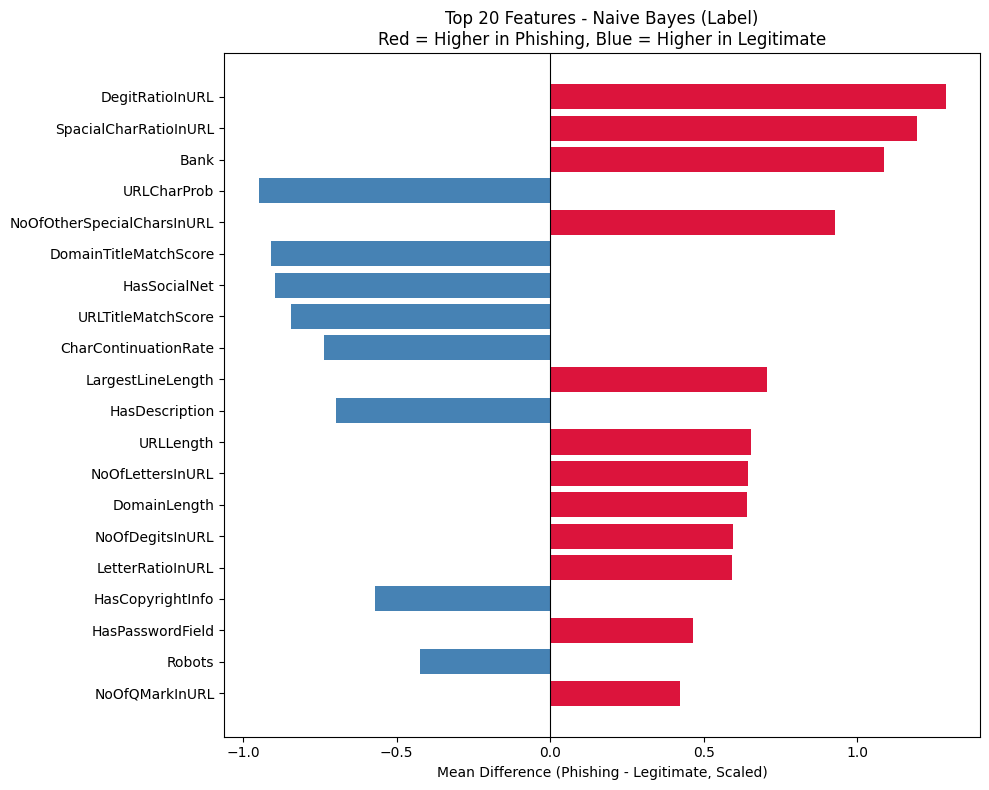

In [ ]:
# Top Features - Naive Bayes
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df['label'] = y_HighRiskPay    
 
class_means = X_scaled_df.groupby('label').mean()
signed_diff = (class_means.loc[1] - class_means.loc[0])
top_features_nb = signed_diff.abs().sort_values(ascending=False).head(20).index
nb_plot_df = signed_diff[top_features_nb]
 
plt.figure(figsize=(10, 8))
colors = ['crimson' if v > 0 else 'steelblue' for v in nb_plot_df.values]
plt.barh(nb_plot_df.index, nb_plot_df.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Naive Bayes (Label)\nRed = Higher in HRP, Blue = Higher in Legitimate')
plt.xlabel('Mean Difference (HRP - Legitimate, Scaled)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

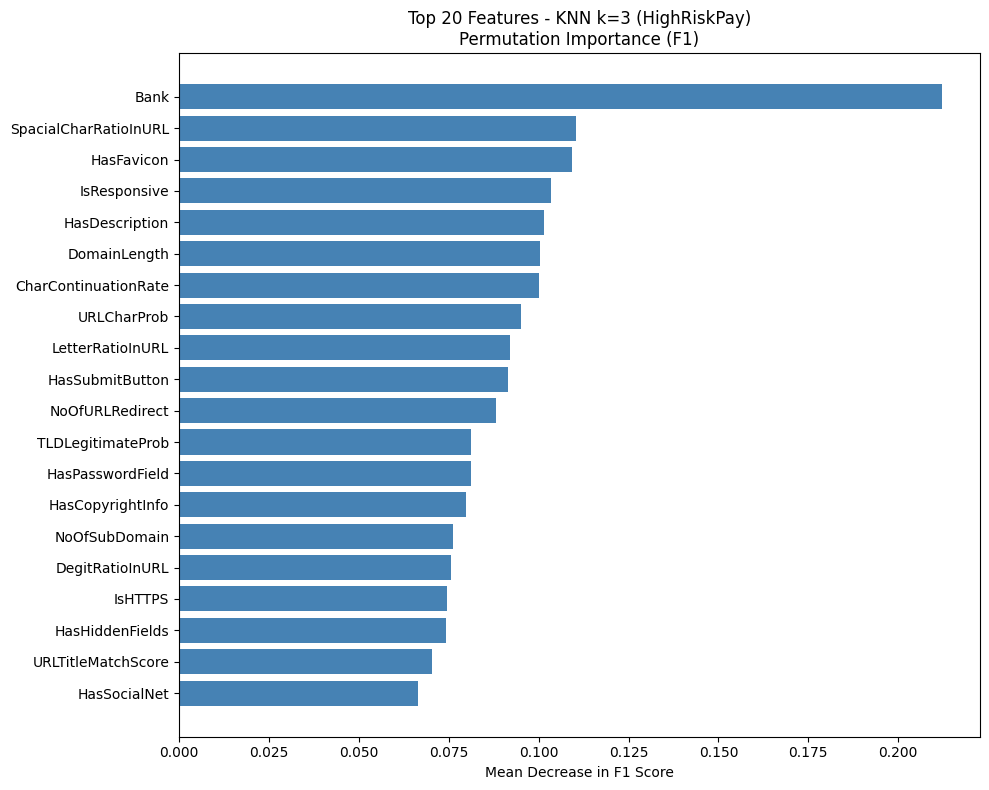

In [10]:
# Top Features from KNN
from sklearn.inspection import permutation_importance
 
# Refit KNN on a subsample to keep runtime reasonable
sample_size = 10000
np.random.seed(42)
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx]
y_sample = y_HighRiskPay[idx] # Ensure Task 1 target is used

# Using k=3 as per your Task 1 results
knn_task1 = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='minkowski', p=2)
knn_task1.fit(X_sample, y_sample)

perm_result = permutation_importance(knn_task1, X_sample, y_sample, n_repeats=5, scoring='f1', random_state=42)

perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_result.importances_mean
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(perm_df['Feature'], perm_df['Importance'], color='steelblue')
plt.title('Top 20 Features - KNN k=3 (HighRiskPay)\nPermutation Importance (F1)')
plt.xlabel('Mean Decrease in F1 Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Deployment

The `HighRiskPay` model is specialized for financial fraud detection. Its deployment would provide a targeted layer of defense specifically tailored to block the most damaging attacks. The value of the model would be measured by its ability to reduce successful phishing attacks while minimizing false positives that incorrectly block legitimate websites. Because phishing strategies evolve over time, the model would need to be retrained periodically using updated data to ensure that it continues to detect new attack patterns effectively.

## Predicting the `label` Variable

In this section, we replicate the modeling process to predict the primary `label` variable (phishing vs. legitimate) using the same three classification algorithms: Logistic Regression, Naive Bayes, and K-Nearest Neighbors. This establishes a baseline detection system for identifying general phishing sites based on URL and structural anomalies.

While the first task focuses on identifying "High Risk Payment" sites, our second task aims to classify websites as Phishing (1) or Legitimate (0) using the same features from task one.

## Logistic Regression for Label

In [11]:
# log reg for label
lr_label = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs')

lr_label_results = CVHelper(
    clf=lr_label,
    X=X,
    y=y_label,
    cv_object=cv_label,
    scale=True,   # turn scaling on
    model_name="Logistic Regression for Label"
)

Iteration 1 - Logistic Regression for Label Metrics:
Accuracy: 0.9994
Precision: 0.9994
Recall: 0.9997
F1-Score: 0.9995
Confusion Matrix:
[[20087    17]
 [    9 26961]]

Iteration 2 - Logistic Regression for Label Metrics:
Accuracy: 0.9993
Precision: 0.9994
Recall: 0.9994
F1-Score: 0.9994
Confusion Matrix:
[[20087    17]
 [   15 26955]]

Iteration 3 - Logistic Regression for Label Metrics:
Accuracy: 0.9995
Precision: 0.9996
Recall: 0.9995
F1-Score: 0.9996
Confusion Matrix:
[[20094    10]
 [   13 26957]]

Iteration 4 - Logistic Regression for Label Metrics:
Accuracy: 0.9994
Precision: 0.9993
Recall: 0.9996
F1-Score: 0.9994
Confusion Matrix:
[[20085    19]
 [   11 26959]]

Iteration 5 - Logistic Regression for Label Metrics:
Accuracy: 0.9992
Precision: 0.9991
Recall: 0.9994
F1-Score: 0.9993
Confusion Matrix:
[[20080    24]
 [   15 26955]]

Average Logistic Regression for Label Metrics over 5 iterations:
Average Accuracy: 0.9994
Average Precision: 0.9994
Average Recall: 0.9995
Average F1-

## Naive Bayes for Label

In [12]:
# nb for label
nb_label = GaussianNB()

nb_label_results = CVHelper(
    clf=nb_label,
    X=X,
    y=y_label,
    cv_object=cv_label,
    scale=True,   # Needed since the features are on different scales
    model_name="Naive Bayes for Label"
)

Iteration 1 - Naive Bayes for Label Metrics:
Accuracy: 0.9366
Precision: 0.9006
Recall: 0.9996
F1-Score: 0.9475
Confusion Matrix:
[[17128  2976]
 [   10 26960]]

Iteration 2 - Naive Bayes for Label Metrics:
Accuracy: 0.9368
Precision: 0.9011
Recall: 0.9994
F1-Score: 0.9477
Confusion Matrix:
[[17146  2958]
 [   17 26953]]

Iteration 3 - Naive Bayes for Label Metrics:
Accuracy: 0.9381
Precision: 0.9028
Recall: 0.9996
F1-Score: 0.9487
Confusion Matrix:
[[17202  2902]
 [   12 26958]]

Iteration 4 - Naive Bayes for Label Metrics:
Accuracy: 0.9378
Precision: 0.9025
Recall: 0.9993
F1-Score: 0.9485
Confusion Matrix:
[[17193  2911]
 [   18 26952]]

Iteration 5 - Naive Bayes for Label Metrics:
Accuracy: 0.9369
Precision: 0.9012
Recall: 0.9993
F1-Score: 0.9477
Confusion Matrix:
[[17150  2954]
 [   18 26952]]

Average Naive Bayes for Label Metrics over 5 iterations:
Average Accuracy: 0.9372
Average Precision: 0.9017
Average Recall: 0.9994
Average F1-Score: 0.9480


## K-Nearest Neighbors for Label

In [13]:
# knn for label
knn_label_results_list = []

for k in (3, 5, 7, 9, 11, 13, 15):  # 3 - 15 Odds only
    knn_label_clf = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='minkowski',
        p=2
    )
    result = CVHelper(
        clf=knn_label_clf,
        X=X,
        y=y_label,
        cv_object=cv_label,
        scale=True,
        model_name=f"KNN (k={k}) for Label"
    )
    knn_label_results_list.append(result)

knn_label_df = pd.DataFrame(knn_label_results_list)
display(knn_label_df)

# Pick best model by highest F1-Score
best_label_idx = knn_label_df['F1-Score'].idxmax()
best_label_row = knn_label_df.loc[best_label_idx]
knn_label_results = knn_label_df.loc[best_label_idx].to_dict()

print("\nBest KNN configuration based on F1-Score for Label:")
print(best_label_row)

Iteration 1 - KNN (k=3) for Label Metrics:
Accuracy: 0.9978
Precision: 0.9973
Recall: 0.9989
F1-Score: 0.9981
Confusion Matrix:
[[20030    74]
 [   31 26939]]

Iteration 2 - KNN (k=3) for Label Metrics:
Accuracy: 0.9982
Precision: 0.9979
Recall: 0.9991
F1-Score: 0.9985
Confusion Matrix:
[[20046    58]
 [   25 26945]]

Iteration 3 - KNN (k=3) for Label Metrics:
Accuracy: 0.9984
Precision: 0.9979
Recall: 0.9992
F1-Score: 0.9986
Confusion Matrix:
[[20048    56]
 [   21 26949]]

Iteration 4 - KNN (k=3) for Label Metrics:
Accuracy: 0.9980
Precision: 0.9975
Recall: 0.9990
F1-Score: 0.9983
Confusion Matrix:
[[20037    67]
 [   26 26944]]

Iteration 5 - KNN (k=3) for Label Metrics:
Accuracy: 0.9979
Precision: 0.9974
Recall: 0.9990
F1-Score: 0.9982
Confusion Matrix:
[[20033    71]
 [   27 26943]]

Average KNN (k=3) for Label Metrics over 5 iterations:
Average Accuracy: 0.9981
Average Precision: 0.9976
Average Recall: 0.9990
Average F1-Score: 0.9983
Iteration 1 - KNN (k=5) for Label Metrics:
Acc

,Model,Accuracy,Precision,Recall,F1-Score,F1_all,Recall_all
0,KNN (k=3) for Label,0.998063,0.997586,0.999036,0.998310,"[0.9980549432228665, 0.9984621940599929, 0.998...","[0.9988505747126437, 0.9990730441230997, 0.999..."
1,KNN (k=5) for Label,0.997752,0.997253,0.998828,0.998040,"[0.9981100611450806, 0.9979065933048037, 0.998...","[0.9986651835372636, 0.9986281053021876, 0.998..."
2,KNN (k=7) for Label,0.997799,0.997364,0.998799,0.998081,"[0.9979433399418206, 0.9984988046036659, 0.998...","[0.9985168705969596, 0.9988134964775677, 0.998..."
3,KNN (k=9) for Label,0.997570,0.997039,0.998725,0.997881,"[0.9976476689696049, 0.9982772992497916, 0.998...","[0.9985539488320356, 0.9991101223581758, 0.999..."
4,KNN (k=11) for Label,0.997642,0.997076,0.998813,0.997944,"[0.9979625856640119, 0.9979997036598015, 0.997...","[0.9988876529477196, 0.9989618094178717, 0.998..."
5,KNN (k=13) for Label,0.997476,0.996781,0.998821,0.997800,"[0.9977776954702026, 0.9979072136308917, 0.997...","[0.9988505747126437, 0.9989247311827957, 0.998..."
6,KNN (k=15) for Label,0.997540,0.996869,0.998843,0.997855,"[0.9980740027408422, 0.9977405733758056, 0.997...","[0.9991472005932518, 0.9987764182424916, 0.998..."



Best KNN configuration based on F1-Score for Label:
Model                                       KNN (k=3) for Label
Accuracy                                               0.998063
Precision                                              0.997586
Recall                                                 0.999036
F1-Score                                                0.99831
F1_all        [0.9980549432228665, 0.9984621940599929, 0.998...
Recall_all    [0.9988505747126437, 0.9990730441230997, 0.999...
Name: 0, dtype: object


## Performance Metrics Comparison Table (Label)

The following table summarizes the performance of the three classification algorithms across a 5 fold stratified cross-validation.

In [14]:
# Building Table for all the label models and their metrics
all_label_results = [lr_label_results, nb_label_results, knn_label_results]
label_results_df = pd.DataFrame(all_label_results)
display(label_results_df)

,Model,Accuracy,Precision,Recall,F1-Score,F1_all,Recall_all
0,Logistic Regression for Label,0.999363,0.999355,0.999533,0.999444,"[0.9995180544227775, 0.9994067702346965, 0.999...","[0.9996662958843159, 0.9994438264738599, 0.999..."
1,Naive Bayes for Label,0.937222,0.901651,0.999444,0.948032,"[0.9475275014936914, 0.9476978252843656, 0.948...","[0.9996292176492398, 0.9993696700037078, 0.999..."
2,KNN (k=3) for Label,0.998063,0.997586,0.999036,0.998310,"[0.9980549432228665, 0.9984621940599929, 0.998...","[0.9988505747126437, 0.9990730441230997, 0.999..."


In [15]:
# 95% CI for F1 for All Label Models
print_ci("Logistic Regression (Label)", lr_label_results["F1_all"])
print_ci("Naive Bayes (Label)", nb_label_results["F1_all"])
print_ci("KNN (Label)", knn_label_results["F1_all"])

Logistic Regression (Label) F1 95% CI: mean=0.9994, CI=(0.9993, 0.9995)
Naive Bayes (Label) F1 95% CI: mean=0.9480, CI=(0.9476, 0.9485)
KNN (Label) F1 95% CI: mean=0.9983, CI=(0.9981, 0.9985)


## Model Evaluation and Trade-Offs

- **Logistic Regression (Winner)**: With an F1-Score of 0.9994 and an extremely tight 95% confidence interval, Logistic Regression demonstrates both exceptional performance and remarkable consistency across all five cross-validation iterations. The narrow CI indicates the model generalizes reliably. It is not getting lucky on any single split.
Its Precision of 0.9993 means that when the model flags a URL as phishing, it is correct virtually every time, minimizing false alarms. Its Recall of 0.9995 means it catches nearly every actual phishing URL, leaving very few threats undetected. In a security context like phishing detection, both matter: false negatives (missed phishing) are dangerous, and false positives (blocking legitimate sites) erode user trust. Logistic Regression balances both nearly perfectly.

- **Naive Bayes**: Although Naive Bayes achieved the highest recall, it has lower precision. While it catches almost every instance of phishing, there are significantly more false positives than other models.
  
- **KNN (Runner-up)**: A significant computational cost for marginally lower performance than the Logistic Regression model.

In summary, Logistic Regression is the recommended model for label prediction. It is the most accurate, most consistent, fastest to train, and best balanced between Precision and Recall.

## Feature Importance (Label)

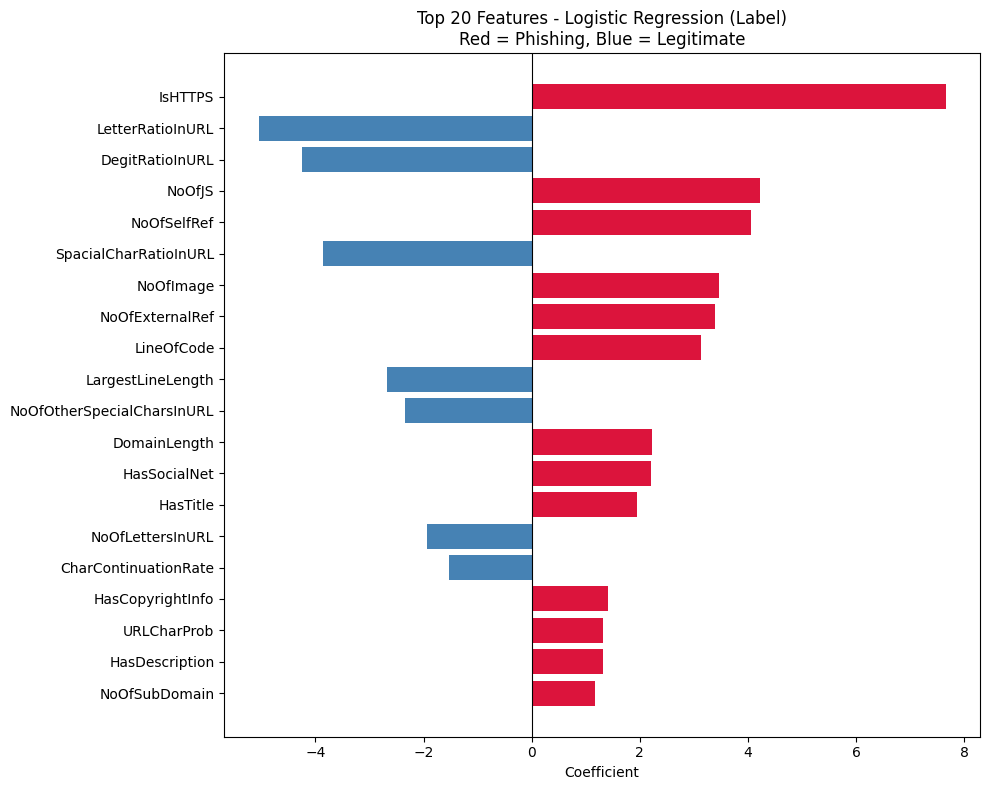

In [16]:
# Top Features - Logistic Regression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
lr_label_full = LogisticRegression(C=1, class_weight='balanced', solver='lbfgs', max_iter=1000)
lr_label_full.fit(X_scaled, y_label)
 
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_label_full.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)
 
plt.figure(figsize=(10, 8))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Logistic Regression (Label)\nRed = Phishing, Blue = Legitimate')
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

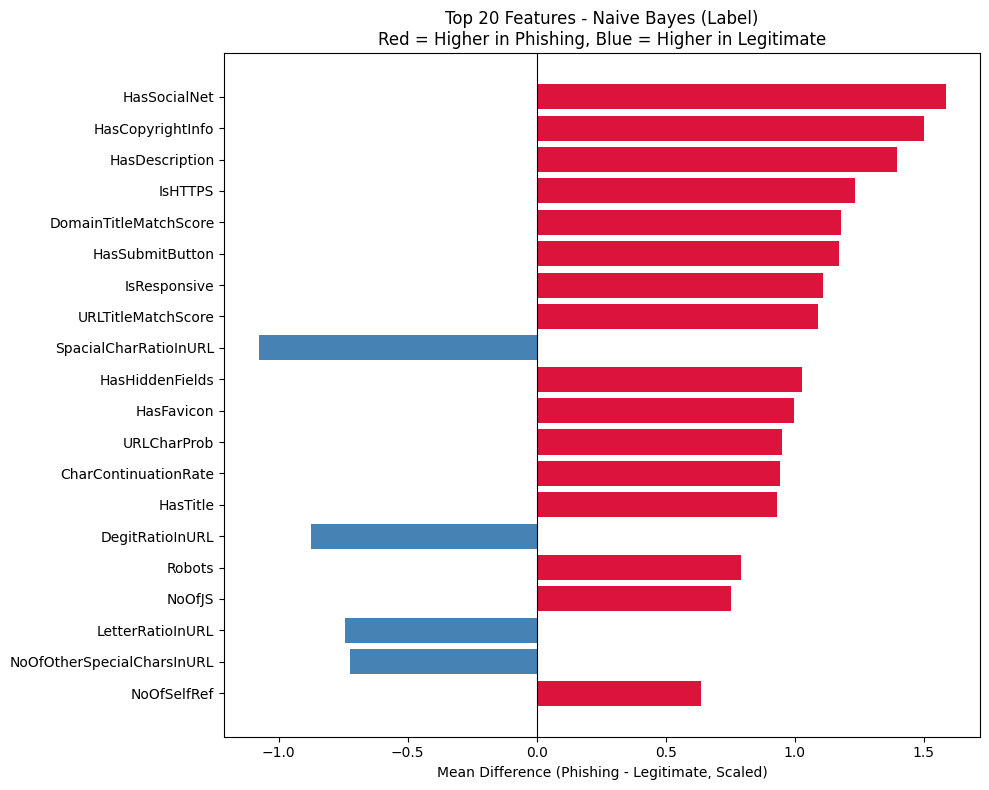

In [17]:
# Top Features - Naive Bayes
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df['label'] = y_label
 
class_means = X_scaled_df.groupby('label').mean()
signed_diff = (class_means.loc[1] - class_means.loc[0])
top_features_nb = signed_diff.abs().sort_values(ascending=False).head(20).index
nb_plot_df = signed_diff[top_features_nb]
 
plt.figure(figsize=(10, 8))
colors = ['crimson' if v > 0 else 'steelblue' for v in nb_plot_df.values]
plt.barh(nb_plot_df.index, nb_plot_df.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - Naive Bayes (Label)\nRed = Higher in Phishing, Blue = Higher in Legitimate')
plt.xlabel('Mean Difference (Phishing - Legitimate, Scaled)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

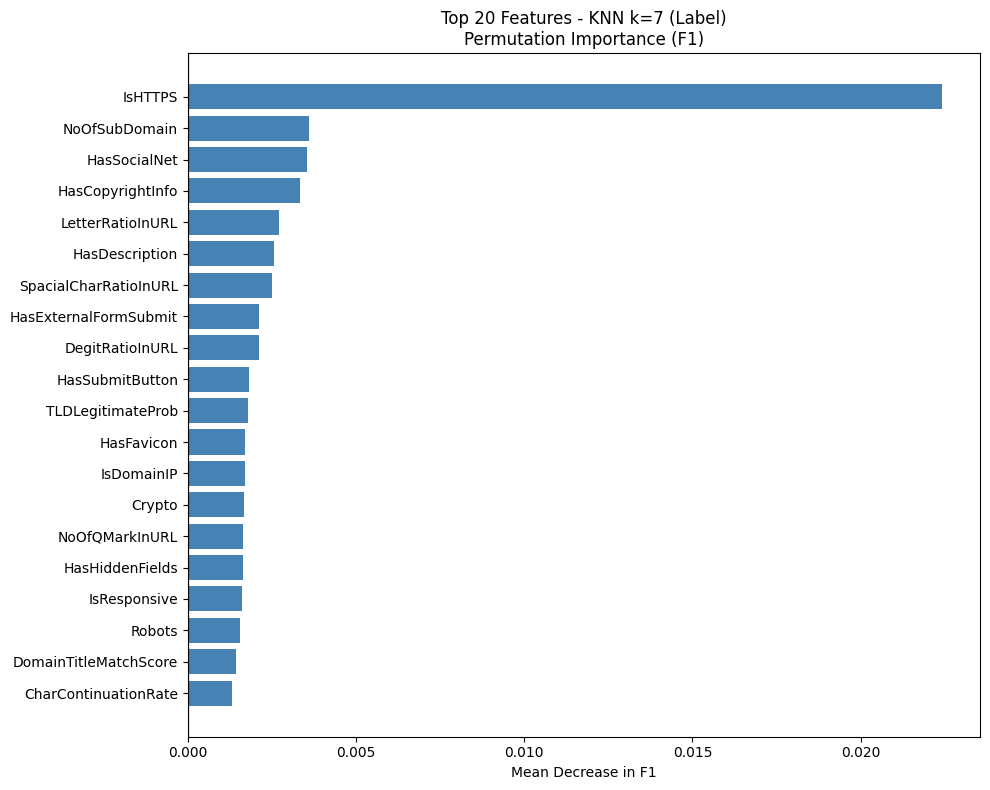

In [18]:
# Top Features from KNN
from sklearn.inspection import permutation_importance
 
sample_size = 10000
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx]
y_sample = y_label[idx]
 
knn_label_full = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='minkowski', p=2)
knn_label_full.fit(X_sample, y_sample)
 
perm_result = permutation_importance(knn_label_full, X_sample, y_sample, n_repeats=5, scoring='f1', random_state=42)
 
perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False).head(20)
 
plt.figure(figsize=(10, 8))
plt.barh(perm_df['Feature'], perm_df['Importance'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features - KNN k=7 (Label)\nPermutation Importance (F1)')
plt.xlabel('Mean Decrease in F1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Deployment

The general label models could be integrated into cybersecurity systems such as browser security filters, enterprise email gateways, or financial fraud monitoring platforms. In a real-world environment, the model would analyze website features in real time and flag suspicious websites before users interact with them.

# Conclusion and Project Summary

This project successfully developed and evaluated machine learning pipelines designed to classify phishing websites, addressing a critical vulnerability in modern network defense. By analyzing the structural characteristics of URLs and webpage attributes, these models provide an automated layer of protection against malicious actors attempting to steal credentials and financial data.

Our modeling strategy was divided into two distinct, progressive objectives:

- Task 1 (High-Risk Payments): We isolated the most severe financial threats by engineering the HighRiskPay (HRP) variable. This allowed us to specifically target fraudulent sites equipped with payment processing functionalities.

- Task 2 (General Phishing): We established a baseline detection system using the label target to identify broad phishing patterns and structural anomalies across all observations.


Future Outlook & Deployment:
Moving forward, implementing a sequential pipeline where the generalized phishing probability from the Task 2 model feeds directly into the Task 1 HRP model as an engineered feature could significantly enhance targeted accuracy. Ultimately, deploying these models into browser security filters, email gateways, or financial monitoring systems offers a robust, scalable defense capable of adapting to the constantly evolving tactics used in modern cybercrime.